In [2]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.path import Path
from matplotlib.patches import PathPatch
import matplotlib
import colormaps as cmaps
from matplotlib.colors import ListedColormap
import pandas as pd

In [3]:
LPJML_baseline = xr.open_dataset('/home/druijsch/LPJmL5/dev15oct2025/config_files/2026_03_27_global_droughtmort/check_output_with_fire/GPP_LPJML_baseline_01deg_MYD_mean.nc').GPP
LPJML_monthlymort = xr.open_dataset('/home/druijsch/LPJmL5/dev15oct2025/config_files/2026_03_27_global_droughtmort/check_output_with_fire/GPP_LPJML_monthlymort_01deg_MYD_mean.nc').GPP
LPJML_droughtmort = xr.open_dataset('/home/druijsch/LPJmL5/dev15oct2025/config_files/2026_04_23_global_droughtmort_new/check_output_with_fire/GPP_LPJML_droughtmort_01deg_MYD_mean.nc').GPP
LPJML_droughtmort

<xarray.DataArray 'GPP' (lat: 1397, lon: 3600)> Size: 20MB
[5029200 values with dtype=float32]
Coordinates:
  * lat      (lat) float64 11kB -55.95 -55.85 -55.75 ... 83.45 83.55 83.65
  * lon      (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.8 179.9 180.0
Attributes:
    units:          gC/m2/month
    standard_name:  GPP
    long_name:      GPP

In [4]:
MODIS = xr.open_dataset("/projects/prjs2023/chapter3/GPP_during_MYDs/GPP_MODIS_01deg_MYD_mean.nc").Gpp
MODIS

<xarray.DataArray 'Gpp' (lat: 1397, lon: 3600)> Size: 40MB
[5029200 values with dtype=float64]
Coordinates:
  * lat      (lat) float64 11kB -55.95 -55.85 -55.75 ... 83.45 83.55 83.65
  * lon      (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.8 179.9 180.0

In [5]:
lc = xr.open_dataset("/projects/prjs2023/chapter3/landcover/C3S-LC-L4-LCCS-Map-01deg_remapnn-P1Y-2022-v2.1.1.nc").lccs_class[0].sel(lat = slice(-56.0,83.7))
lc['lat'] = LPJML_monthlymort.lat
lc['lon'] = LPJML_monthlymort.lon
valid_mask = (lc != 220) & (lc != 210) & (lc != 200) & (lc != 150)

In [6]:
# Step 1: Rename variables before merging
MODIS = MODIS.rename("GPP_MODIS").where(valid_mask)
LPJML_monthlymort = LPJML_monthlymort.rename("GPP_LPJML_monthlymort").where(valid_mask)
LPJML_baseline = LPJML_baseline.rename("GPP_LPJML_baseline").where(valid_mask)
LPJML_droughtmort = LPJML_droughtmort.rename("GPP_LPJML_droughtmort").where(valid_mask)

# Step 2: Merge datasets
ds = xr.merge([MODIS, LPJML_monthlymort, LPJML_baseline, LPJML_droughtmort])
ds = ds.reset_coords("time", drop=True)
ds

<xarray.Dataset> Size: 101MB
Dimensions:                (lon: 3600, lat: 1397)
Coordinates:
  * lon                    (lon) float64 29kB -179.9 -179.8 ... 179.9 180.0
  * lat                    (lat) float64 11kB -55.95 -55.85 ... 83.55 83.65
Data variables:
    GPP_MODIS              (lat, lon) float64 40MB nan nan nan ... nan nan nan
    GPP_LPJML_monthlymort  (lat, lon) float32 20MB nan nan nan ... nan nan nan
    GPP_LPJML_baseline     (lat, lon) float32 20MB nan nan nan ... nan nan nan
    GPP_LPJML_droughtmort  (lat, lon) float32 20MB nan nan nan ... nan nan nan

/scratch-local/77370/ipykernel_2756617/1455253286.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmaps.vegetation_ClarkU, num_colors)


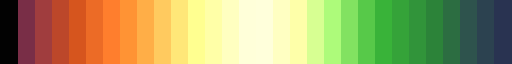

In [7]:
# Number of discrete colors to use
num_colors = 30

# Get the vegetation_ClarkU colormap
cmap = plt.cm.get_cmap(cmaps.vegetation_ClarkU, num_colors)

# Define brightness change parameters
outer_brightness = 0.01
middle_brightness = 0.4

# Calculate brightness changes
brightness_changes = np.linspace(outer_brightness, middle_brightness, num_colors // 2)

# Modify the colors to make yellow and green lighter
colors = cmap(np.linspace(0, 1, num_colors))
colors[:num_colors // 2] += brightness_changes[:, np.newaxis]  # Increase brightness for yellow
colors[num_colors // 2:] += brightness_changes[::-1][:, np.newaxis]  # Increase brightness for green

# Ensure colors stay within the valid RGBA range of 0 to 1
colors = colors.clip(0.0, 1.0)

# Create a ListedColormap object
discrete_cmap = ListedColormap(colors)
discrete_cmap



In [8]:
def plot_four_worldmaps_with_violin_inset(
    input_data_list,        # List of 4 xarray datasets
    discrete_cmap,
    vmin, vmax,
    cbar_label,
    extend,
    title_list,             # List of 4 titles
    ds,
    savefig=False
):

    fig, axes = plt.subplots(
        nrows=2,
        ncols=2,
        subplot_kw={'projection': ccrs.PlateCarree(central_longitude=11)},
        figsize=(16, 12)
    )

    axes = axes.flatten()
    subplot_labels = ['a)', 'b)', 'c)', 'd)', 'e)']
    combined_titles = [f"{subplot_labels[i]} {title}" for i, title in enumerate(title_list)]
    
    # === Spatial correlations vs MODIS (robust) ===
    modis_full = ds.GPP_MODIS.values.flatten()

    corrs = []
    models = [
        ds.GPP_LPJML_baseline.values.flatten(),
        ds.GPP_LPJML_monthlymort.values.flatten(),
        ds.GPP_LPJML_droughtmort.values.flatten()
    ]

    for model in models:
        mask = np.isfinite(model) & np.isfinite(modis_full)
        corr = np.corrcoef(model[mask], modis_full[mask])[0, 1]
        corrs.append(corr)
    


    # === Plot 4 worldmaps ===
    for idx, ax in enumerate(axes):
        ax.axis('off')

        im = input_data_list[idx].plot(
            ax=ax,
            add_colorbar=False,
            transform=ccrs.PlateCarree(),
            cmap=discrete_cmap,
            vmin=vmin,
            vmax=vmax
        )

        ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
        ax.add_feature(cfeature.LAND)

        ax.set_title(combined_titles[idx], fontsize=14, fontweight='bold', loc='left')

        # === Add correlation on maps for panels 2,3,4 ===
        if idx in (1, 2, 3):
            # corrs list corresponds to [baseline, monthly, drought] -> map panels 1,2,3 are these
            corr_value = corrs[idx - 1]
            ax.text(
                0.98, 0.02,                          # bottom-right corner
                f"r = {corr_value:.2f}",
                transform=ax.transAxes,
                fontsize=11,
                ha='right',
                va='bottom',
                bbox=dict(
                    facecolor='white',
                    alpha=0.7,
                    edgecolor='none',
                    boxstyle='round,pad=0.2'
                )
            )

    # === Shared colorbar ===
    cbar_ax = fig.add_axes([0.95, 0.2, 0.02, 0.6])
    cb = fig.colorbar(im, cax=cbar_ax, orientation='vertical', extend=extend)
    cb.set_label(cbar_label, labelpad=15, fontsize=14)

    # === Prepare violin data (4 datasets) ===
    data_arrays = [
        ds.GPP_MODIS.values.flatten(),
        ds.GPP_LPJML_baseline.values.flatten(),
        ds.GPP_LPJML_monthlymort.values.flatten(),
        ds.GPP_LPJML_droughtmort.values.flatten()   
    ]

    cleaned = []
    for d in data_arrays:
        d = d[np.isfinite(d)]
        cleaned.append(d)

    clipped_data = [d[(d >= vmin) & (d <= vmax)] for d in cleaned]


    # === Violin inset ===
    violin_ax = fig.add_axes([1.15, 0.25, 0.13, 0.4])

    violin = violin_ax.violinplot(
        clipped_data,
        showmedians=True,
        showextrema=True
    )

    violin_ax.set_title(subplot_labels[4], fontsize=12, loc='left', fontweight='bold')
    violin_ax.set_xticks([1, 2, 3, 4])
    violin_ax.set_xticklabels(
        ["MODIS", "Baseline", "Monthly background mortality", "Drought mortality"],
        fontsize=9,
        rotation=20
    )
    violin_ax.set_ylabel(r"GPP$_{\mathrm{SA}}$ during MYDs", fontsize=10)

    # Style
    violin['cmedians'].set_color('black')
    violin['cbars'].set_color('black')
    violin['cbars'].set_linewidth(1.5)
    violin['cmins'].set_color('none')
    violin['cmaxes'].set_color('none')
    
    # === Add correlation text ===
    labels = ["Baseline", "Monthly mort", "Drought mort"]
    text_y = 0.95
    for i, (lab, c) in enumerate(zip(labels, corrs)):
        violin_ax.text(
            1.05, text_y - i*0.08,
            f"{lab}: r = {c:.2f}",
            transform=violin_ax.transAxes,
            fontsize=9,
            va='top'
        )

    # === Gradient fill ===
    ymin, ymax = violin_ax.get_ylim()
    xmin, xmax = violin_ax.get_xlim()

    Nx, Ny = 1, 50
    imgArr = np.tile(np.linspace(vmin, vmax, Ny), (Nx, 1)).T
    norm = matplotlib.colors.Normalize(vmin=vmin, vmax=vmax)

    for body in violin['bodies']:
        body.set_facecolor('none')

    for body in violin['bodies']:
        path = Path(body.get_paths()[0].vertices)
        patch = PathPatch(path, facecolor='none', edgecolor='none')
        violin_ax.add_patch(patch)

        violin_ax.imshow(
            imgArr,
            origin="lower",
            extent=[xmin, xmax, vmin, vmax],
            aspect="auto",
            cmap=discrete_cmap,
            norm=norm,
            clip_path=patch,
            clip_on=True
        )

    # === Outliers ===
    outliers = [d[(d < vmin) | (d > vmax)] for d in cleaned]

    for i, o in enumerate(outliers):
        violin_ax.scatter(
            np.full(o.shape, i+1),
            o,
            color="gray",
            s=3,
            alpha=0.6
        )

    # === Save or show ===
    if savefig:
        plt.savefig("four_map_violin.png", dpi=1200, bbox_inches='tight')
    else:
        plt.show()

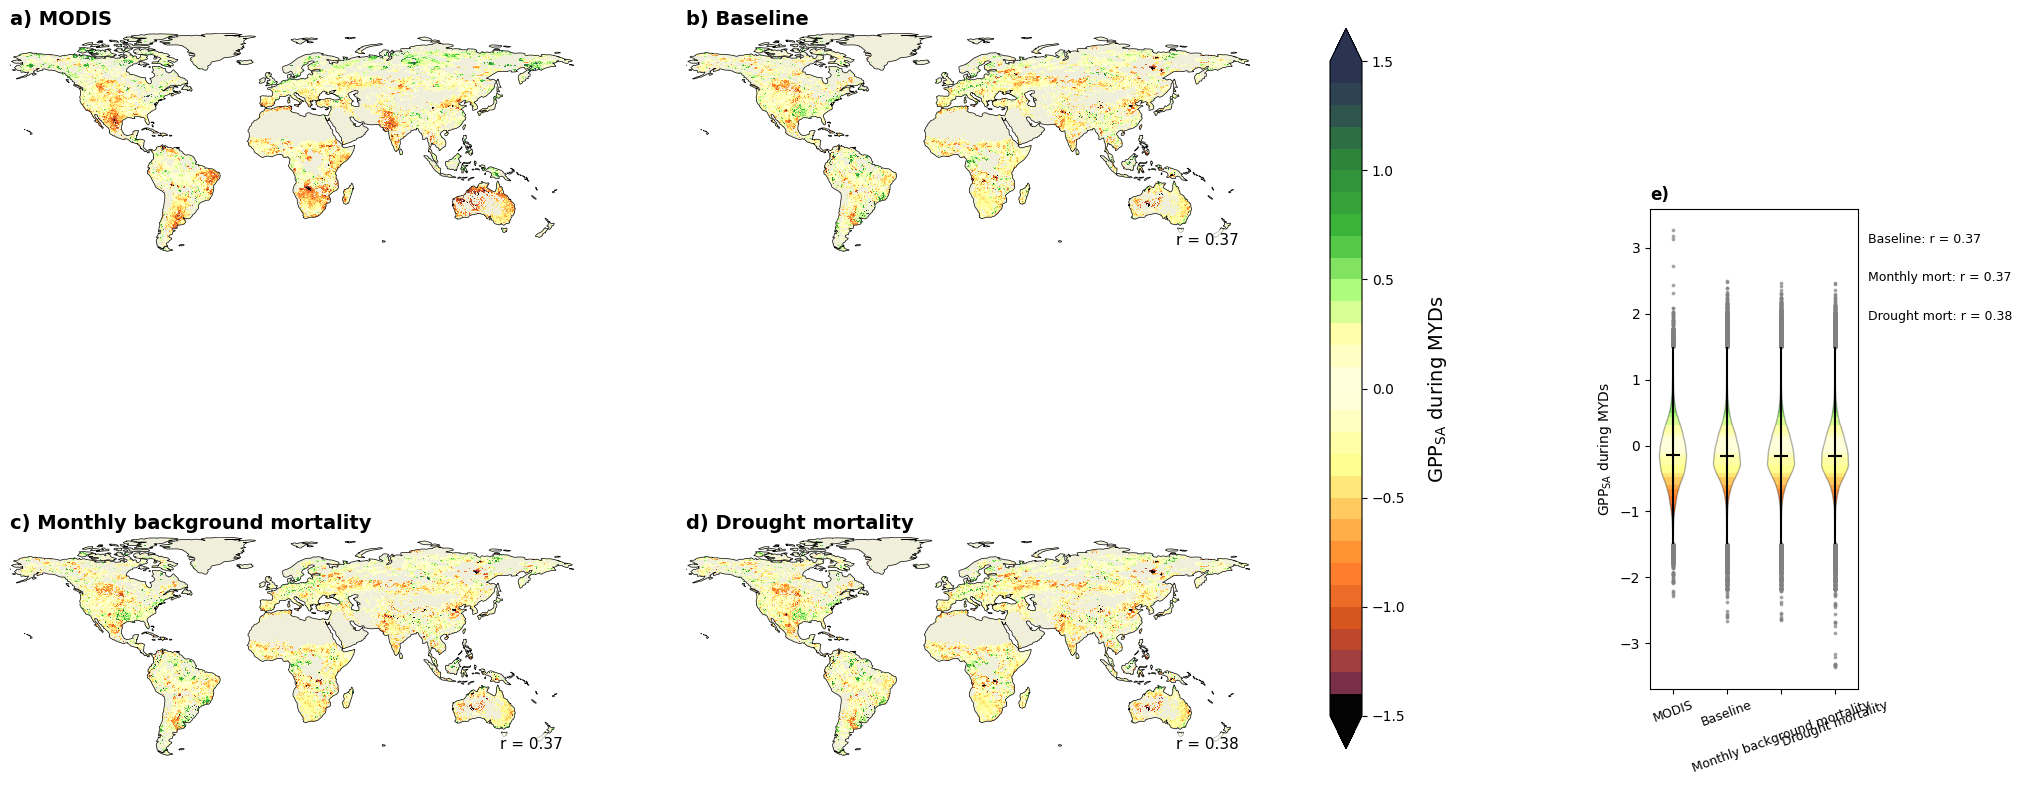

In [9]:
plot_four_worldmaps_with_violin_inset(
    input_data_list=[ds.GPP_MODIS, ds.GPP_LPJML_baseline, ds.GPP_LPJML_monthlymort, ds.GPP_LPJML_droughtmort],  
    discrete_cmap=discrete_cmap,               # Main map colormap
    vmin=-1.5,
    vmax=1.5,
    cbar_label=r"GPP$_{\mathrm{SA}}$ during MYDs",
    extend='both',
    title_list=["MODIS", "Baseline", "Monthly background mortality", "Drought mortality"],
    ds=ds,
    savefig=False
)